In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader,TensorDataset
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

/home/anmino/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.drop("id",axis=1,inplace=True)

In [4]:
df.head(2)

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,female,64,163.0,60.0,8.0,85.0,39.7,34.0


In [5]:
df["Sex"] = pd.get_dummies(df["Sex"],drop_first=True,dtype="int")

In [6]:
df

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,1,36,189.0,82.0,26.0,101.0,41.0,150.0
1,0,64,163.0,60.0,8.0,85.0,39.7,34.0
2,0,51,161.0,64.0,7.0,84.0,39.8,29.0
3,1,20,192.0,90.0,25.0,105.0,40.7,140.0
4,0,38,166.0,61.0,25.0,102.0,40.6,146.0
...,...,...,...,...,...,...,...,...
749995,1,28,193.0,97.0,30.0,114.0,40.9,230.0
749996,0,64,165.0,63.0,18.0,92.0,40.5,96.0
749997,1,60,162.0,67.0,29.0,113.0,40.9,221.0
749998,1,45,182.0,91.0,17.0,102.0,40.3,109.0


In [7]:
x = df.drop("Calories",axis=1).values
y = df["Calories"].values

In [8]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [9]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [10]:
scaler_2 = StandardScaler()
y_train = scaler.fit_transform(y_train.reshape(-1,1))
y_test = scaler.transform(y_test.reshape(-1,1))

In [11]:
x_train = torch.tensor(x_train,dtype=torch.float32)
x_test = torch.tensor(x_test,dtype=torch.float32)

y_train = torch.tensor(y_train,dtype=torch.float32)
y_test = torch.tensor(y_test,dtype=torch.float32)

In [12]:
train_dataset = TensorDataset(
    x_train,y_train
)

test_dataset = TensorDataset(
    x_test,y_test
)

In [13]:
train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    batch_size=100
)

test_loader = DataLoader(
    test_dataset,
    shuffle=True,
    batch_size=100
)

In [14]:
class ResidualBlock(nn.Module):
    def __init__(self,dim):
        super().__init__()
        self.fc1 = nn.Linear(dim,dim)
        self.ln1 = nn.LayerNorm(dim)

        self.fc2 = nn.Linear(dim,dim)
        self.ln2 = nn.LayerNorm(dim)

        self.gelu = nn.GELU()

    def forward(self,x):
        identity = x

        out = self.fc1(x)
        out = self.ln1(out)
        out = self.gelu(out)

        out = self.fc2(out)
        out = self.ln2(out)

        out = out + identity

        out = self.gelu(out)

        return out

In [15]:
class MyModel(nn.Module):
    def __init__(self,input_dim):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(in_features=input_dim,out_features=128),
            nn.LayerNorm(128),
            nn.GELU()
        )

        self.res1 = ResidualBlock(128)
        self.res2 = ResidualBlock(128)

        self.output_layer = nn.Linear(128,1)

    def forward(self,x):
        x = self.input_layer(x)

        x = self.res1(x)
        x = self.res2(x)

        x = self.output_layer(x)

        return x

In [16]:
model = MyModel(input_dim=7)

In [17]:
for name,param in model.named_parameters():
    print(name,param.shape)

input_layer.0.weight torch.Size([128, 7])
input_layer.0.bias torch.Size([128])
input_layer.1.weight torch.Size([128])
input_layer.1.bias torch.Size([128])
res1.fc1.weight torch.Size([128, 128])
res1.fc1.bias torch.Size([128])
res1.ln1.weight torch.Size([128])
res1.ln1.bias torch.Size([128])
res1.fc2.weight torch.Size([128, 128])
res1.fc2.bias torch.Size([128])
res1.ln2.weight torch.Size([128])
res1.ln2.bias torch.Size([128])
res2.fc1.weight torch.Size([128, 128])
res2.fc1.bias torch.Size([128])
res2.ln1.weight torch.Size([128])
res2.ln1.bias torch.Size([128])
res2.fc2.weight torch.Size([128, 128])
res2.fc2.bias torch.Size([128])
res2.ln2.weight torch.Size([128])
res2.ln2.bias torch.Size([128])
output_layer.weight torch.Size([1, 128])
output_layer.bias torch.Size([1])


In [18]:
model

MyModel(
  (input_layer): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): GELU(approximate='none')
  )
  (res1): ResidualBlock(
    (fc1): Linear(in_features=128, out_features=128, bias=True)
    (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (fc2): Linear(in_features=128, out_features=128, bias=True)
    (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (gelu): GELU(approximate='none')
  )
  (res2): ResidualBlock(
    (fc1): Linear(in_features=128, out_features=128, bias=True)
    (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (fc2): Linear(in_features=128, out_features=128, bias=True)
    (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (gelu): GELU(approximate='none')
  )
  (output_layer): Linear(in_features=128, out_features=1, bias=True)
)

In [19]:
loss_function = nn.MSELoss()

optimizer_function = torch.optim.AdamW(model.parameters(),
                                       lr=0.001,
                                       weight_decay=0.01)

In [20]:
train_loss_hist = []
test_loss_hist = []

epochs = 50
process_bar = tqdm(range(epochs),colour="blue")

for epoch in process_bar:
    model.train()
    total_train_loss = 0
    for batch_train_x,batch_train_y in train_loader:
        optimizer_function.zero_grad()
        train_prediction = model(batch_train_x)
        loss = loss_function(train_prediction,batch_train_y)
        loss.backward()
        optimizer_function.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss   / len(train_loader)

    model.eval()
    total_test_loss = 0
    with torch.no_grad():
        for batch_test_x,batch_test_y in test_loader:
            test_prediction = model(batch_test_x)
            test_loss = loss_function(test_prediction,batch_test_y)
            total_test_loss += test_loss.item()
    avg_test_loss = total_test_loss / len(test_loader)
    
    train_loss_hist.append(avg_train_loss)
    test_loss_hist.append(avg_test_loss)

    torch.save({
      "Epochs":epoch,
      "Test Loss":avg_test_loss,
      "Train Loss":avg_train_loss,
      "Optimizer":optimizer_function.state_dict(),
      "Model":model.state_dict()  
    },f"residual_model/checkpoint_{epoch+1}.pth")

    process_bar.set_postfix({
        "Epoch":epoch+1,
        "Train Loss":f"{avg_train_loss:.4f}",
        "Test Loss":f"{avg_test_loss:.4f}"
    })


100%|██████████| 50/50 [20:00<00:00, 24.01s/it, Epoch=50, Train Loss=0.0034, Test Loss=0.0033]


In [21]:
import matplotlib.pyplot as plt

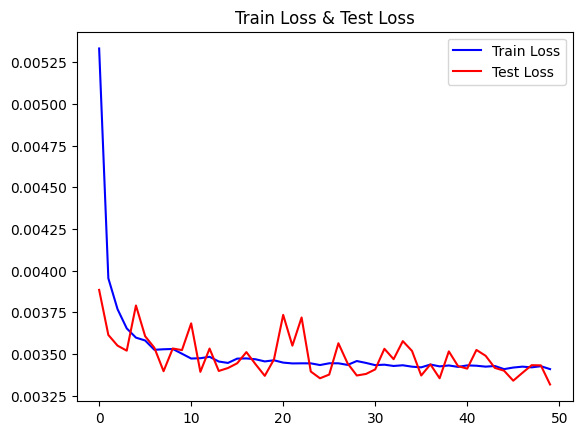

In [27]:
plt.plot(train_loss_hist,label="Train Loss",color="Blue")
plt.plot(test_loss_hist,label="Test Loss",color="red")
plt.title("Train Loss & Test Loss")
plt.legend()
plt.show()